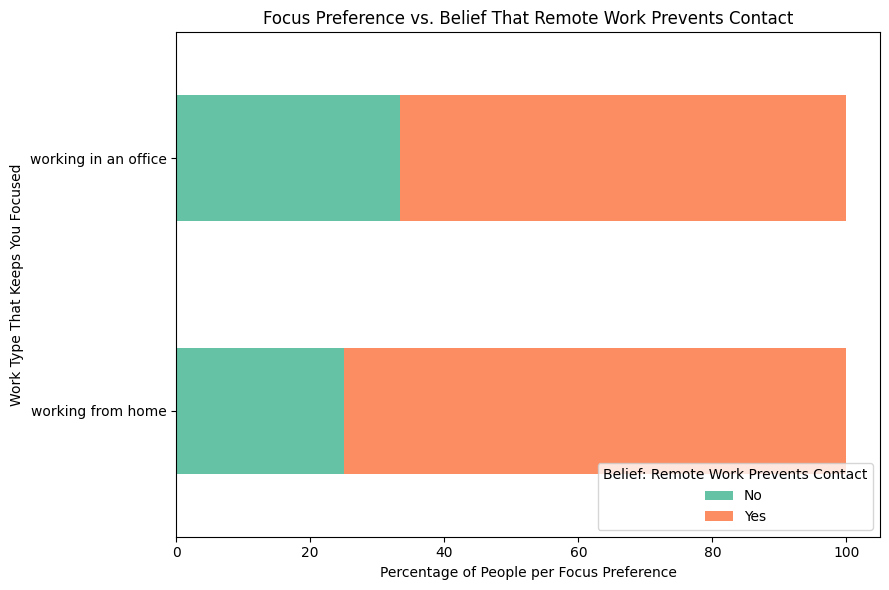

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.mosaicplot import mosaic

df = pd.read_csv('The Impacts of Working Remotely and in an Office Survey.csv')

# Clean and standardize the two relevant columns
df['focus'] = df['Which work type keeps you focused while working?'].str.strip().str.lower()
df['prevents_contact'] = df['Do you think that working from home prevents you from getting in contact with people?'].str.strip().str.lower()

# Filter out rows with missing data in either column
df_clean = df.dropna(subset=['focus', 'prevents_contact'])

df_clean['focus'] = df_clean['focus'].replace({
    'remote work': 'Remote Work Focus',
    'office work': 'Office Work Focus',
    'hybrid work': 'Hybrid Work Focus'
})

crosstab = pd.crosstab(df_clean['focus'], df_clean['prevents_contact'], normalize='index') * 100

crosstab.plot(kind='barh', stacked=True, figsize=(9,6), color=['#66c2a5','#fc8d62'])
plt.title('Focus Preference vs. Belief That Remote Work Prevents Contact')
plt.xlabel('Percentage of People per Focus Preference')
plt.ylabel('Work Type That Keeps You Focused')
plt.legend(title='Belief: Remote Work Prevents Contact', labels=['No', 'Yes'], loc='lower right')
plt.tight_layout()
plt.show()


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('Impact_of_Remote_Work_on_Mental_Health.csv')
print(df['Mental_Health_Condition'].value_counts(dropna=False))



Mental_Health_Condition
Burnout       1280
Anxiety       1278
Depression    1246
NaN           1196
Name: count, dtype: int64


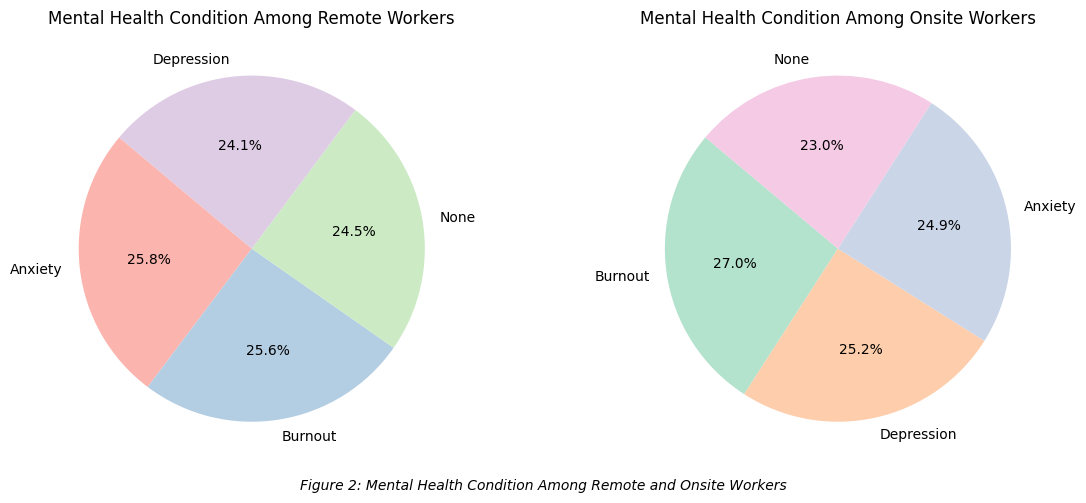

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('Impact_of_Remote_Work_on_Mental_Health.csv')

# Optional: clean column names and values
df.columns = df.columns.str.strip()
df['Work_Location'] = df['Work_Location'].str.strip().str.capitalize()  # Normalize casing

# Replace NaN in Mental_Health_Condition with 'None'
df['Mental_Health_Condition'] = df['Mental_Health_Condition'].fillna('None')

# Create subsets
remote = df[df['Work_Location'] == 'Remote']
onsite = df[df['Work_Location'] == 'Onsite']  # Updated from 'Office' to 'Onsite'

# Count mental health condition distribution for each group, now including 'None'
remote_mh = remote['Mental_Health_Condition'].value_counts()
onsite_mh = onsite['Mental_Health_Condition'].value_counts()

# Plot pie charts
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.pie(remote_mh, labels=remote_mh.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Pastel1.colors)
plt.title('Mental Health Condition Among Remote Workers')

plt.subplot(1, 2, 2)
plt.pie(onsite_mh, labels=onsite_mh.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Pastel2.colors)
plt.title('Mental Health Condition Among Onsite Workers')

plt.figtext(0.5, 0.01, "Figure 2: Mental Health Condition Among Remote and Onsite Workers", ha='center', fontsize=10, style='italic')
plt.tight_layout(rect=[0, 0.03, 1, 1])  # Leave space at the bottom for the caption
plt.show()




This shows that people who work remote have slightly less mental conditions

In [4]:
# Define the desired order
desired_order = ['High', 'Medium', 'Low']

# Reindex the crosstab to that order (it will put NaN if some level missing)
stress_dist = stress_dist.reindex(desired_order)

# Now plot as before
stress_dist.plot(kind='bar', figsize=(8,6), color=['#66c2a5', '#fc8d62'])
plt.title('Stress Level Distribution: Remote vs Onsite Workers')
plt.ylabel('Percentage of Workers')
plt.xlabel('Stress Level')
plt.xticks(rotation=0)
plt.legend(title='Work Location', loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()


NameError: name 'stress_dist' is not defined

This shows that workers who work remote have slightly higher stress levels than the workers onsite


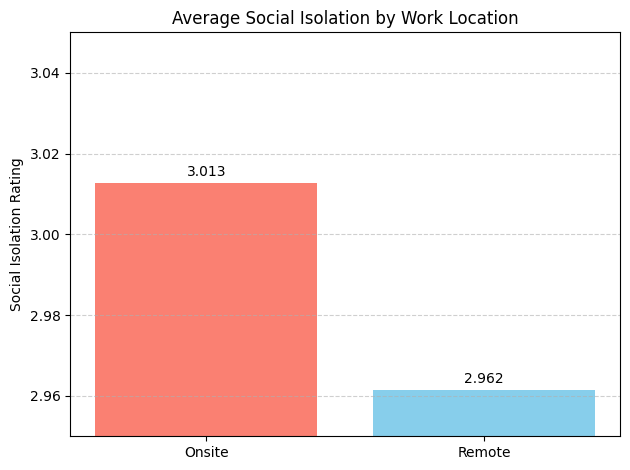

In [36]:
import matplotlib.pyplot as plt

avg_isolation = {
    'Onsite': 3.0128,
    'Remote': 2.9615
}

plt.bar(avg_isolation.keys(), avg_isolation.values(), color=['salmon', 'skyblue'])
plt.title('Average Social Isolation by Work Location')
plt.ylabel('Social Isolation Rating')

# Zoom in on y-axis to highlight the small difference
plt.ylim(2.95, 3.05)  # Focusing on the narrow range

# Add exact values on top of bars
for i, (label, value) in enumerate(avg_isolation.items()):
    plt.text(i, value + 0.001, f"{value:.3f}", ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [84]:
data = pd.read_csv('Impact_of_Remote_Work_on_Mental_Health.csv')

Perspectief 2

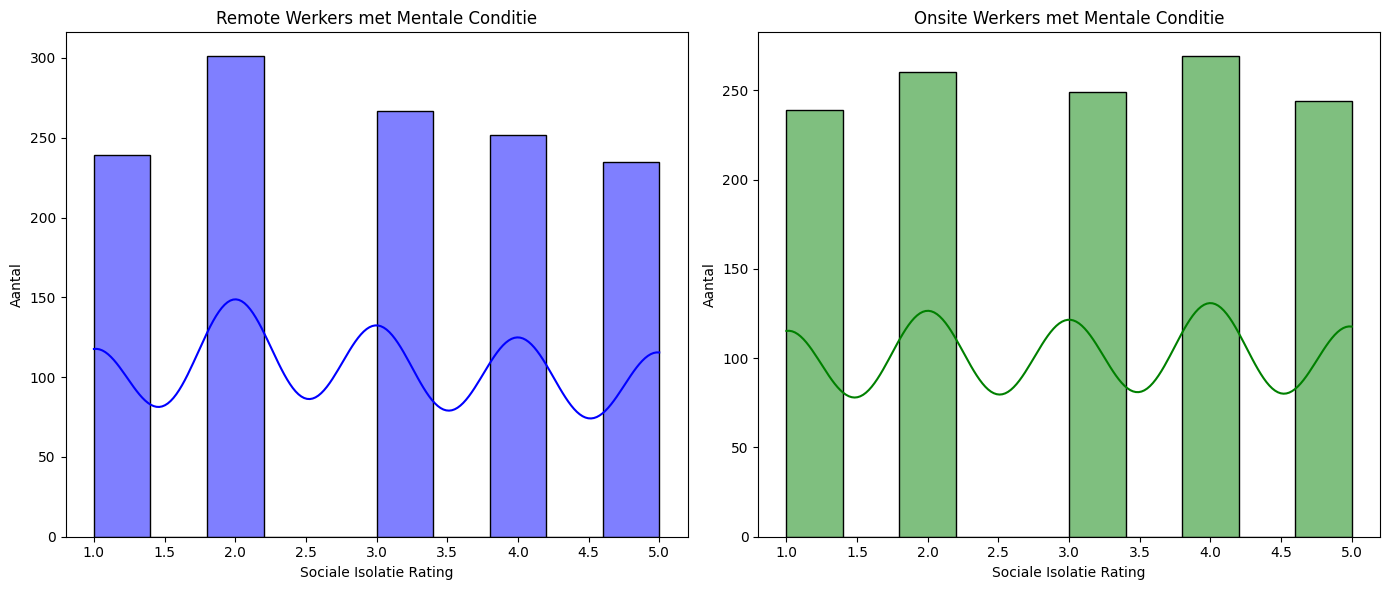

Remote werkers met mentale condities:
Mediaan: 3.0
Gemiddelde: 2.955950540958269

Onsite werkers met mentale condities:
Mediaan: 3.0
Gemiddelde: 3.015067406819984


In [113]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv('Impact_of_Remote_Work_on_Mental_Health.csv')

# Filter mensen met mentale gezondheidsconditie
data_mental = data[data['Mental_Health_Condition'].notnull() & (data['Mental_Health_Condition'] != '')]

# Gemiddelde productiviteitsverandering per werkplek
mean_prod = data_mental.groupby('Work_Location')['Productivity_Change'].mean()
print(mean_prod)

# Visualisatie
sns.boxplot(data=data_mental, x='Work_Location', y='Productivity_Change')
plt.title('Productiviteitsverandering per werkplek (met mentale gezondheidscondities)')
plt.show()

TypeError: agg function failed [how->mean,dtype->object]

Remote: Correlatie tussen uren en productiviteit = -0.06, p-waarde = 0.186
In-Office: Correlatie tussen uren en productiviteit = 0.04, p-waarde = 0.371


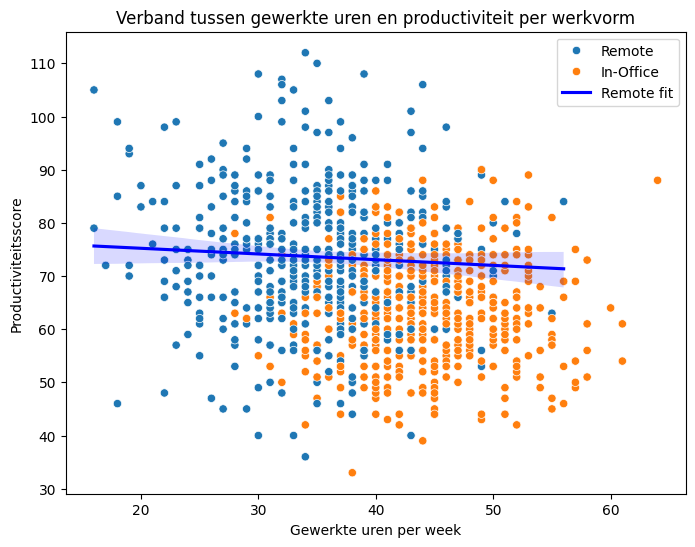

In [111]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Data inlezen
data = pd.read_csv('remote_work_productivity.csv')

# Correlatie per Employment_Type
for emp_type in data['Employment_Type'].unique():
    subset = data[data['Employment_Type'] == emp_type]
    corr, p_val = pearsonr(subset['Hours_Worked_Per_Week'], subset['Productivity_Score'])
    print(f"{emp_type}: Correlatie tussen uren en productiviteit = {corr:.2f}, p-waarde = {p_val:.3f}")

# Scatterplot met regressielijn
plt.figure(figsize=(8,6))
sns.scatterplot(data=data, x='Hours_Worked_Per_Week', y='Productivity_Score', hue='Employment_Type')
sns.regplot(data=data[data['Employment_Type']=='Remote'], x='Hours_Worked_Per_Week', y='Productivity_Score', scatter=False, label='Remote fit', color='blue')
sns.regplot(data=data[data['Employment_Type']=='Onsite'], x='Hours_Worked_Per_Week', y='Productivity_Score', scatter=False, label='Onsite fit', color='orange')

plt.title('Verband tussen gewerkte uren en productiviteit per werkvorm')
plt.xlabel('Gewerkte uren per week')
plt.ylabel('Productiviteitsscore')
plt.legend()
plt.show()


In [121]:
import pandas as pd

# Stel je data heet data.csv
data = pd.read_csv('The Impacts of Working Remotely and in an Office Survey.csv')

# Fysieke problemen
physical_counts = data['Do you think that working from home saves you more time?'].value_counts()
print("antwoorden:")
print(physical_counts)




antwoorden:
Do you think that working from home saves you more time?
No     60
Yes    40
Name: count, dtype: int64


In [161]:
import pandas as pd

data = pd.read_csv('Impact_of_Remote_Work_on_Mental_Health.csv')

# Leeftijdsgroepen maken
bins = [0, 29, 50, 100]
labels = ['<30', '30-50', '50+']
data['Age_Group'] = pd.cut(data['Age'], bins=bins, labels=labels, include_lowest=True)

# Stresslevel ordinaal maken
stress_order = ['Low', 'Medium', 'High']
data['Stress_Level'] = pd.Categorical(data['Stress_Level'], categories=stress_order, ordered=True)

# Mentale gezondheid categoriseren
data['Has_Mental_Health_Condition'] = data['Mental_Health_Condition'].notnull() & (data['Mental_Health_Condition'] != '')
data['Has_Mental_Health_Condition'] = data['Has_Mental_Health_Condition'].map({True: 'Ja', False: 'Nee'})

def print_mean_hours(df, group_col):
    print(f"\nGemiddelde uren gewerkt per stressniveau binnen {group_col}:")
    mean_df = df.groupby([group_col, 'Stress_Level'])['Hours_Worked_Per_Week'].mean().unstack()
    print(mean_df)

print_mean_hours(data, 'Has_Mental_Health_Condition')
print_mean_hours(data, 'Age_Group')
print_mean_hours(data, 'Gender')



Gemiddelde uren gewerkt per stressniveau binnen Has_Mental_Health_Condition:
Stress_Level                       Low    Medium       High
Has_Mental_Health_Condition                                
Ja                           39.411297  39.76247  39.891745
Nee                          39.262887  39.11330  39.746269

Gemiddelde uren gewerkt per stressniveau binnen Age_Group:
Stress_Level       Low     Medium       High
Age_Group                                   
<30           39.34188  39.513120  40.632653
30-50         38.86270  39.727974  39.996707
50+           40.47381  39.411483  38.946759

Gemiddelde uren gewerkt per stressniveau binnen Gender:
Stress_Level             Low     Medium       High
Gender                                            
Female             39.009709  39.263529  39.020595
Male               39.481395  40.085973  40.464824
Non-binary         39.425000  39.191067  39.408759
Prefer not to say  39.590571  39.852130  40.556818


/var/folders/gr/6dxd183d6tl1p4tg4cw_43t40000gp/T/ipykernel_4596/1149553926.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_df = df.groupby([group_col, 'Stress_Level'])['Hours_Worked_Per_Week'].mean().unstack()
/var/folders/gr/6dxd183d6tl1p4tg4cw_43t40000gp/T/ipykernel_4596/1149553926.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_df = df.groupby([group_col, 'Stress_Level'])['Hours_Worked_Per_Week'].mean().unstack()
/var/folders/gr/6dxd183d6tl1p4tg4cw_43t40000gp/T/ipykernel_4596/1149553926.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a fu

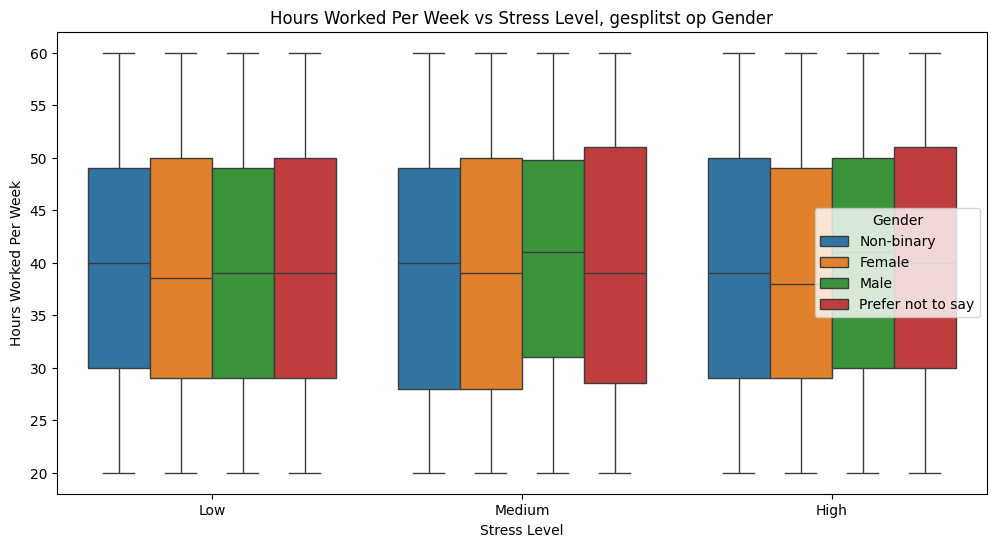

In [187]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Stress_Level', y='Hours_Worked_Per_Week', hue='Gender', data=df1, order=['Low','Medium','High'])
plt.title('Hours Worked Per Week vs Stress Level, gesplitst op Gender')
plt.xlabel('Stress Level')
plt.ylabel('Hours Worked Per Week')
plt.legend(title='Gender')
plt.show()

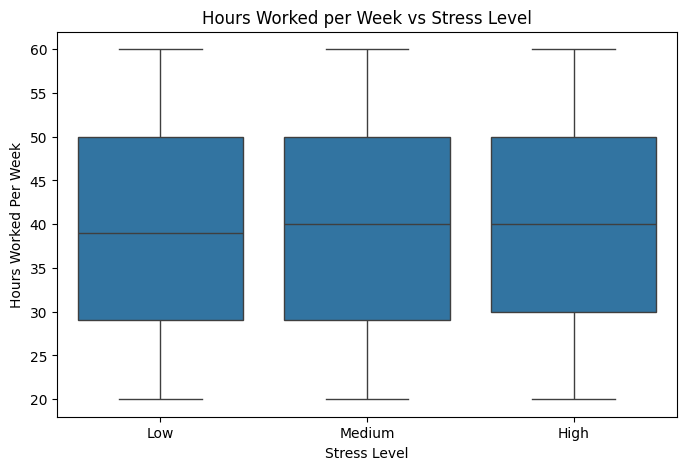

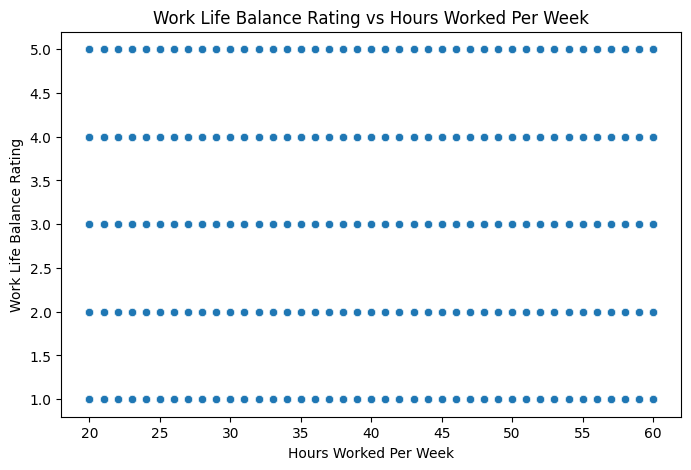

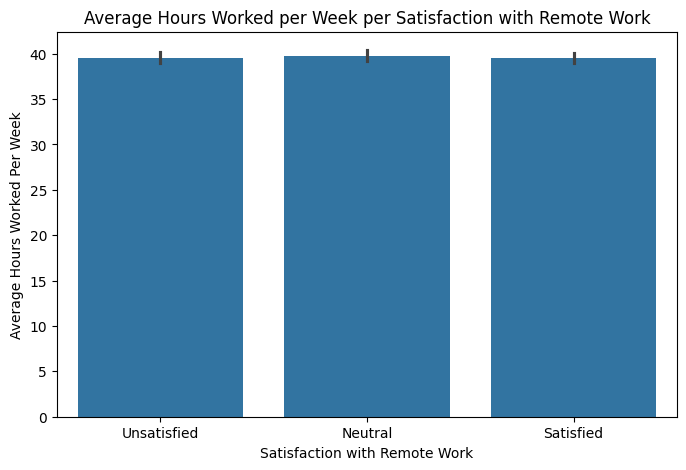

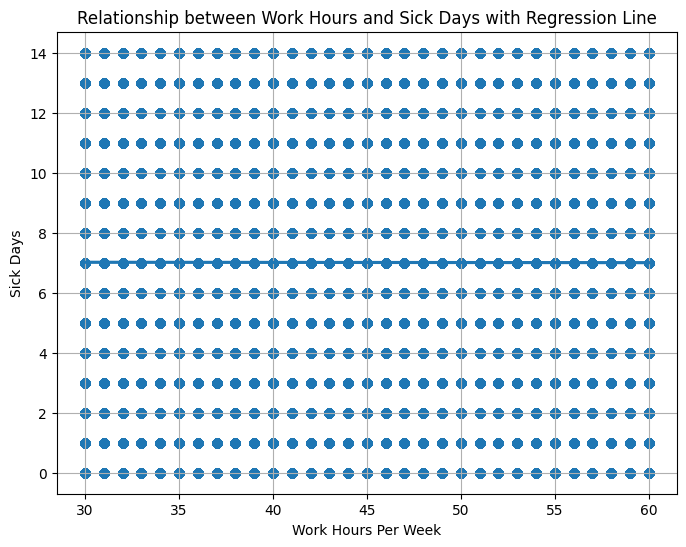

Pearson correlation between Work Hours and Sick Days: -0.001


In [232]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('Extended_Employee_Performance_and_Productivity_Data.csv')

df = df.dropna(subset=['Work_Hours_Per_Week', 'Sick_Days'])

plt.figure(figsize=(8,6))
sns.regplot(x='Work_Hours_Per_Week', y='Sick_Days', data=df, scatter_kws={'alpha':0.5})

plt.xlabel('Work Hours Per Week')
plt.ylabel('Sick Days')
plt.title('Relationship between Work Hours and Sick Days with Regression Line')
plt.grid(True)
plt.show()
corr = df['Work_Hours_Per_Week'].corr(df['Sick_Days'])
print(f'Pearson correlation between Work Hours and Sick Days: {corr:.3f}')


/var/folders/gr/6dxd183d6tl1p4tg4cw_43t40000gp/T/ipykernel_4596/86074542.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  consultants['Hours_Bin'] = pd.cut(consultants['Work_Hours_Per_Week'], bins=bins, labels=labels, right=False).copy()
/var/folders/gr/6dxd183d6tl1p4tg4cw_43t40000gp/T/ipykernel_4596/86074542.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_salary = consultants.groupby('Hours_Bin')['Monthly_Salary'].mean()


Average Monthly Salary per Work Hours Bin for Consultants:
Hours_Bin
30-34    7165.768897
35-39    7145.940078
40-44    7156.623550
45-49    7158.439281
50-54    7146.681034
55-59    7153.331891
Name: Monthly_Salary, dtype: float64


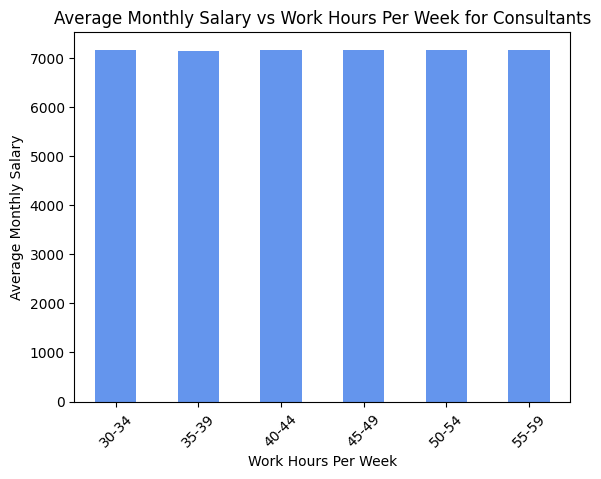

In [272]:
import pandas as pd
import matplotlib.pyplot as plt

# Filter consultants
consultants = data[data['Job_Title'] == 'Consultant']

# Define bins starting at 30 hours
bins = [30, 35, 40, 45, 50, 55, 60]
labels = ['30-34', '35-39', '40-44', '45-49', '50-54', '55-59']

consultants['Hours_Bin'] = pd.cut(consultants['Work_Hours_Per_Week'], bins=bins, labels=labels, right=False).copy()

# Calculate average salary per bin
avg_salary = consultants.groupby('Hours_Bin')['Monthly_Salary'].mean()

# Print the average salaries per bin
print("Average Monthly Salary per Work Hours Bin for Consultants:")
print(avg_salary)

# Plot bar graph
avg_salary.plot(kind='bar', color='cornflowerblue')
plt.xlabel('Work Hours Per Week')
plt.ylabel('Average Monthly Salary')
plt.title('Average Monthly Salary vs Work Hours Per Week for Consultants')
plt.xticks(rotation=45)
plt.show()



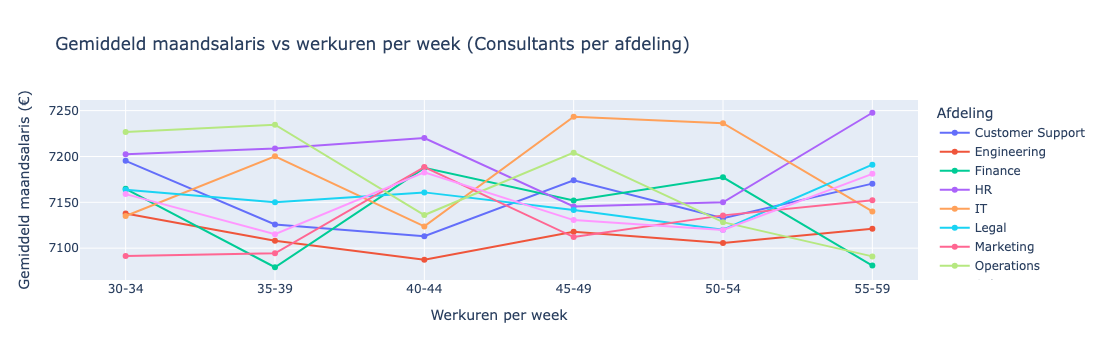

In [288]:
import pandas as pd
import plotly.express as px

# Filter consultants
consultants = data[data['Job_Title'] == 'Consultant'].copy()

# Define bins and labels
bins = [30, 35, 40, 45, 50, 55, 60]
labels = ['30-34', '35-39', '40-44', '45-49', '50-54', '55-59']
consultants['Hours_Bin'] = pd.cut(consultants['Work_Hours_Per_Week'], bins=bins, labels=labels, right=False)

# Group by Department and Hours_Bin and calculate average salary
avg_salary = consultants.groupby(['Department', 'Hours_Bin'], observed=True)['Monthly_Salary'].mean().reset_index()

# Create interactive line plot with Plotly Express
fig = px.line(
    avg_salary,
    x='Hours_Bin',
    y='Monthly_Salary',
    color='Department',
    markers=True,
    labels={
        'Hours_Bin': 'Werkuren per week',
        'Monthly_Salary': 'Gemiddeld maandsalaris (€)',
        'Department': 'Afdeling'
    },
    title='Gemiddeld maandsalaris vs werkuren per week (Consultants per afdeling)'
)

fig.update_layout(xaxis=dict(tickmode='array', tickvals=labels, ticktext=labels))

fig.show()


/var/folders/gr/6dxd183d6tl1p4tg4cw_43t40000gp/T/ipykernel_4596/1382038792.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  consultants['Hours_Bin'] = pd.cut(consultants['Work_Hours_Per_Week'], bins=bins, labels=labels, right=False)
/var/folders/gr/6dxd183d6tl1p4tg4cw_43t40000gp/T/ipykernel_4596/1382038792.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_promotions = consultants.groupby('Hours_Bin')['Promotions'].mean()


Average Promotions per Work Hours Bin for Consultants:
Hours_Bin
30-34    1.013901
35-39    0.956144
40-44    0.999108
45-49    1.018413
50-54    0.986207
55-59    0.983124
Name: Promotions, dtype: float64


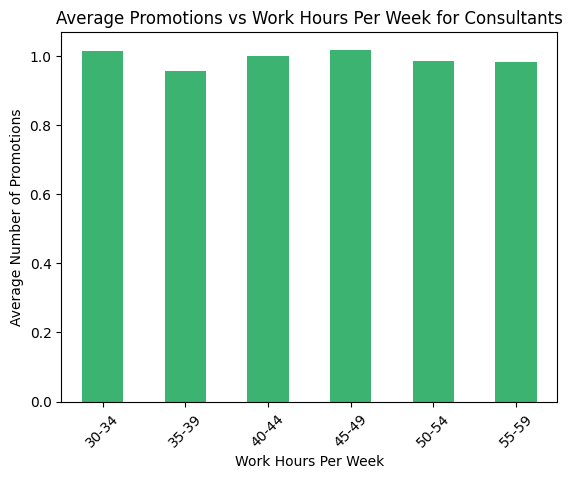

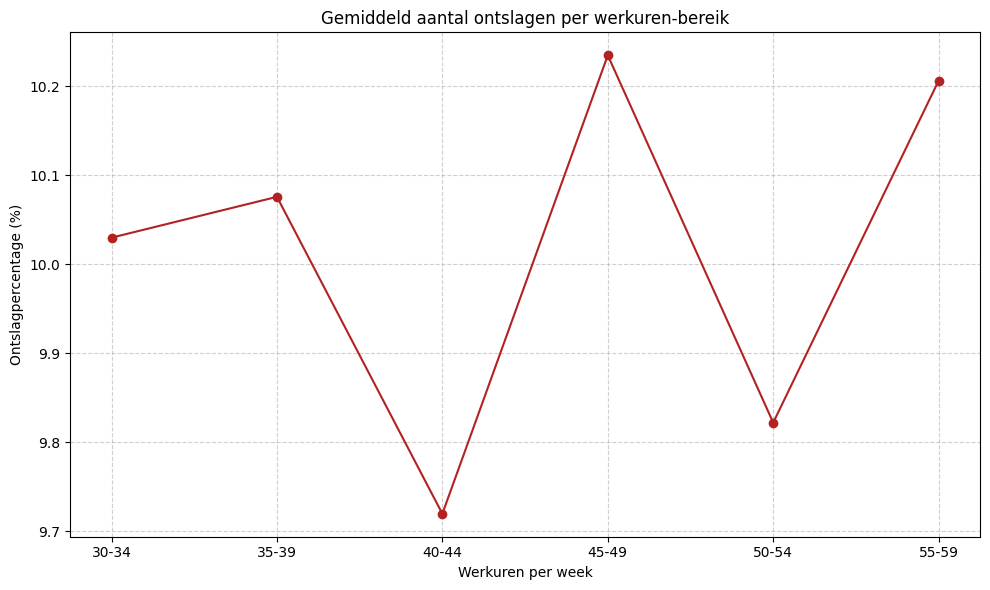

In [274]:

df['Resigned'] = df['Resigned'].astype(bool)
df['Work_Hours_Per_Week'] = pd.to_numeric(df['Work_Hours_Per_Week'], errors='coerce')

# Binning
bins = [30, 35, 40, 45, 50, 55, 60]
labels = ['30-34', '35-39', '40-44', '45-49', '50-54', '55-59']
df['Hours_Bin'] = pd.cut(df['Work_Hours_Per_Week'], bins=bins, labels=labels, right=False)

# Group and calculate avg resignation rate
resignation_rate = df.groupby('Hours_Bin', observed=True)['Resigned'].mean() * 100  # Percentage

# Plotting
plt.figure(figsize=(10,6))
plt.plot(resignation_rate.index, resignation_rate.values, marker='o', linestyle='-', color='firebrick')
plt.title('Gemiddeld aantal ontslagen per werkuren-bereik')
plt.xlabel('Werkuren per week')
plt.ylabel('Ontslagpercentage (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("resignation_vs_hours.png")  # Optional: Save the figure
plt.show()


In [276]:
print(df['Department'].unique())
print(df['Job_Title'].unique())


['IT' 'Finance' 'Customer Support' 'Engineering' 'Marketing' 'HR'
 'Operations' 'Sales' 'Legal']
['Specialist' 'Developer' 'Analyst' 'Manager' 'Technician' 'Engineer'
 'Consultant']


In [278]:
# Snelle check
consultants['Department'].value_counts()


Department
Finance             1640
IT                  1597
Legal               1594
Operations          1590
Sales               1587
HR                  1574
Customer Support    1558
Marketing           1552
Engineering         1518
Name: count, dtype: int64